<a href="https://colab.research.google.com/github/IshaCodex/OIBSIP/blob/main/DataAnalytics-L1-EDARetailSales/Task1_Retail_Sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Inspection & Setup

First, we will import the necessary data manipulation and visualization libraries, load our dataset, and perform an initial inspection to check its shape, data types, and check for any missing values.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/retail_sales_dataset.csv')

# Perform initial inspection
print("Dataset Shape:", df.shape)
print("\n--- Column Data Types ---")
print(df.dtypes)
print("\n--- Null Value Check ---")
print(df.isnull().sum())

Dataset Shape: (1000, 9)

--- Column Data Types ---
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

--- Null Value Check ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


The 'Date' column is currently formatted as a string (object) and will need to be converted to datetime for time series analysis.

In [3]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Descriptive Statistics

Next, we will calculate the mean, median, standard deviation, and mode for our numerical columns to understand the general distribution of our customer ages and purchasing behaviors.

In [4]:
# Calculate standard descriptive statistics (mean, median, std, min, max)
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
display(df[numerical_cols].describe())

,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


Now we will calculate the mode (most frequent value) for the numerical columns.

In [5]:
# Calculate the mode for numerical columns
print("Mode for numerical columns:")
display(df[numerical_cols].mode().iloc[0])

Mode for numerical columns:


,0
Age,43.0
Quantity,4.0
Price per Unit,50.0
Total Amount,50.0


# Time Series Analysis

We will analyze the sales trends over time by plotting both monthly and quarterly revenue to identify seasonal patterns or peak sales periods.

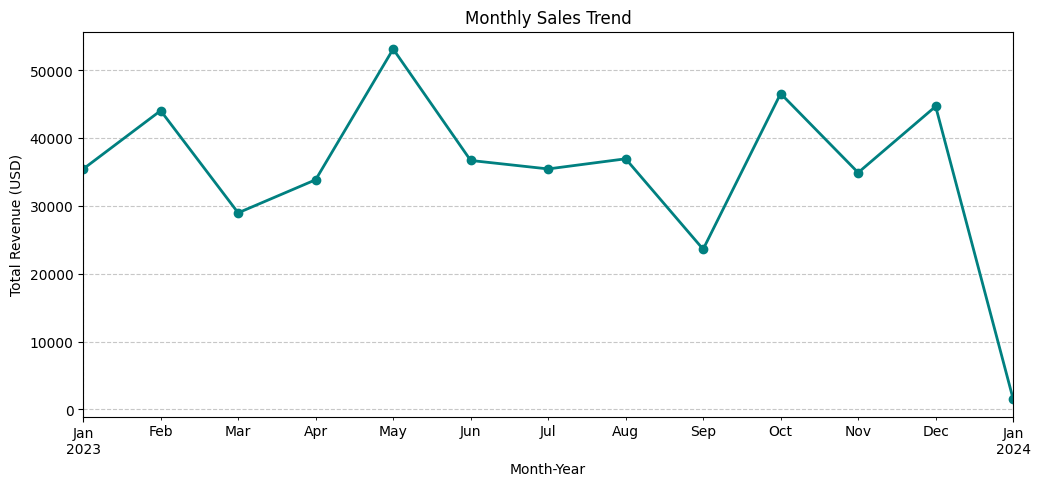

In [6]:
# Create new columns for Month-Year and Quarter
df['Month_Year'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

# Calculate monthly revenue
monthly_sales = df.groupby('Month_Year')['Total Amount'].sum()

# Plot monthly sales trend
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Revenue (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

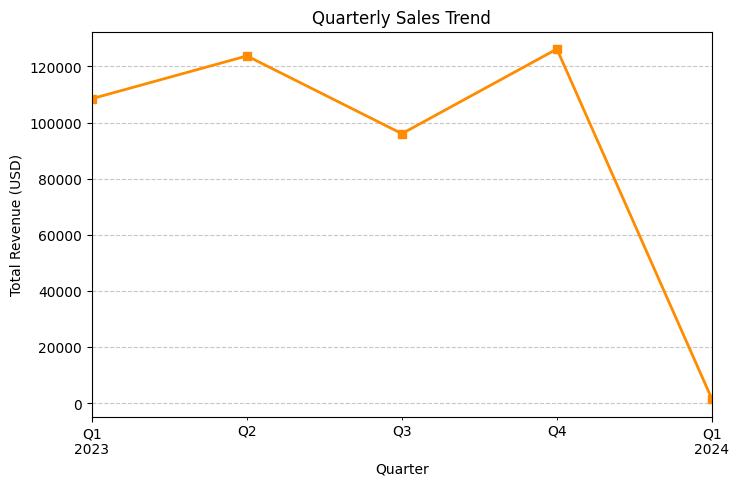

In [7]:
# Calculate quarterly revenue
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

# Plot quarterly sales trend
plt.figure(figsize=(8, 5))
quarterly_sales.plot(kind='line', marker='s', color='darkorange', linewidth=2)
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Customer Demographics Analysis

We will explore the customer base by analyzing the age distribution and the gender breakdown.

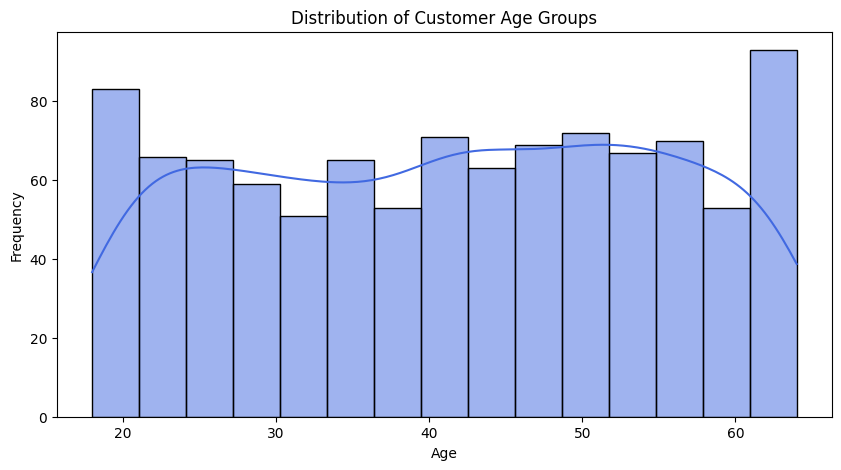

In [8]:
# Plot Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=15, kde=True, color='royalblue')
plt.title('Distribution of Customer Age Groups')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

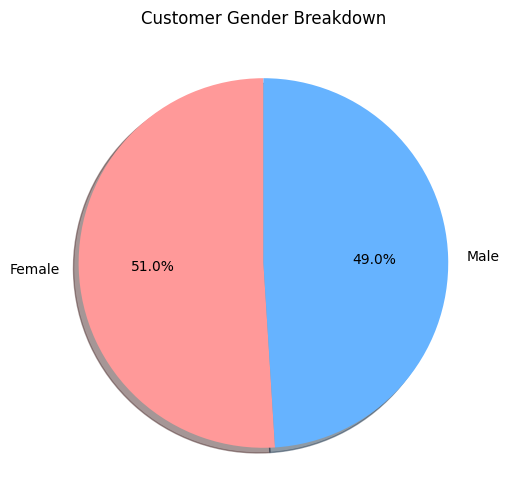

In [9]:
# Plot Gender Breakdown
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff'], startangle=90, shadow=True)
plt.title('Customer Gender Breakdown')
plt.show()

# Product Analysis

Since this dataset categorizes items broadly rather than listing specific product names, we will look at the total revenue generated by each major product category.

/tmp/ipykernel_5407/1998491046.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')


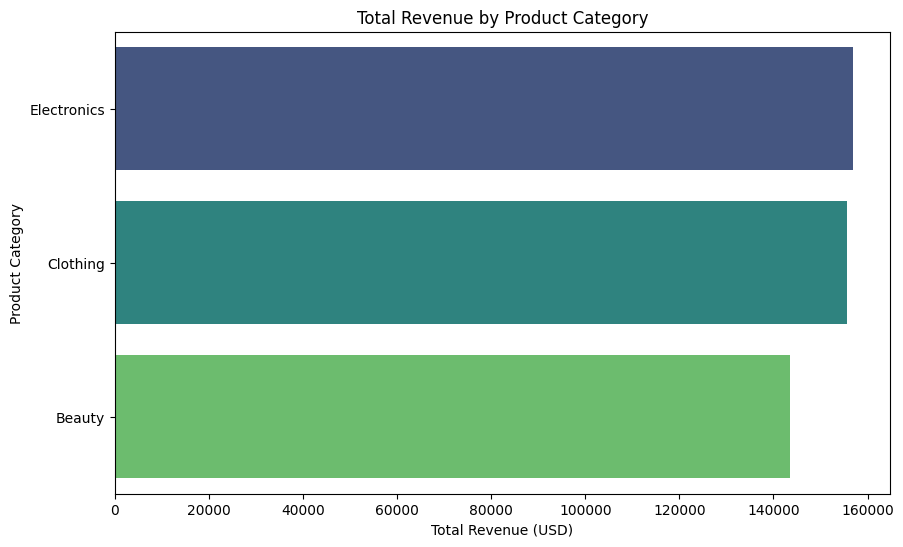

In [10]:
# Calculate revenue by product category
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

# Plot revenue by product category
plt.figure(figsize=(10, 6))
sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
plt.title('Total Revenue by Product Category')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Product Category')
plt.show()

# Correlation Heatmap

We will generate a heatmap to see how numerical variables (like Age, Quantity, and Total Amount) correlate with one another.

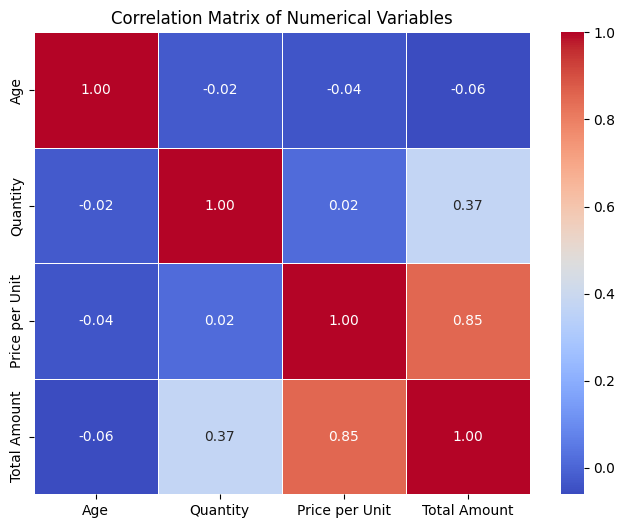

In [11]:
# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# Spending by Gender and Category

To uncover a non-obvious insight, we will analyze if men and women prefer spending their money on different product categories.

In [ ]:
# Calculate total amount spent by gender and category
gender_category_sales = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().unstack()

# Plot grouped bar chart
gender_category_sales.plot(kind='bar', figsize=(10, 6), color=['#ff9999', '#66b3ff'])
plt.title('Total Revenue by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.show()